# Big Mart Sales Prediction
**Goal**: Predict `Item_Outlet_Sales` for 5,681 test records using a regression ensemble.

**Pipeline**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Model Benchmarking — Ridge, Random Forest, XGBoost, LightGBM
4. Best-model Hyperparameter Tuning
5. Final Predictions & Submission

## 0 · Setup

In [1]:
import warnings, json, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

print('All libraries loaded ✓')

All libraries loaded ✓


## 1 · Load Data

In [2]:
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head()

Train: (8523, 12)  |  Test: (5681, 11)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


In [4]:
print('=== Missing values ===')
missing = pd.concat([
    train.isnull().sum().rename('Train'),
    test.isnull().sum().rename('Test')
], axis=1)
missing[missing.sum(axis=1) > 0]

=== Missing values ===


,Train,Test
Item_Weight,1463,976.0
Outlet_Size,2410,1606.0


In [5]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## 2 · Exploratory Data Analysis

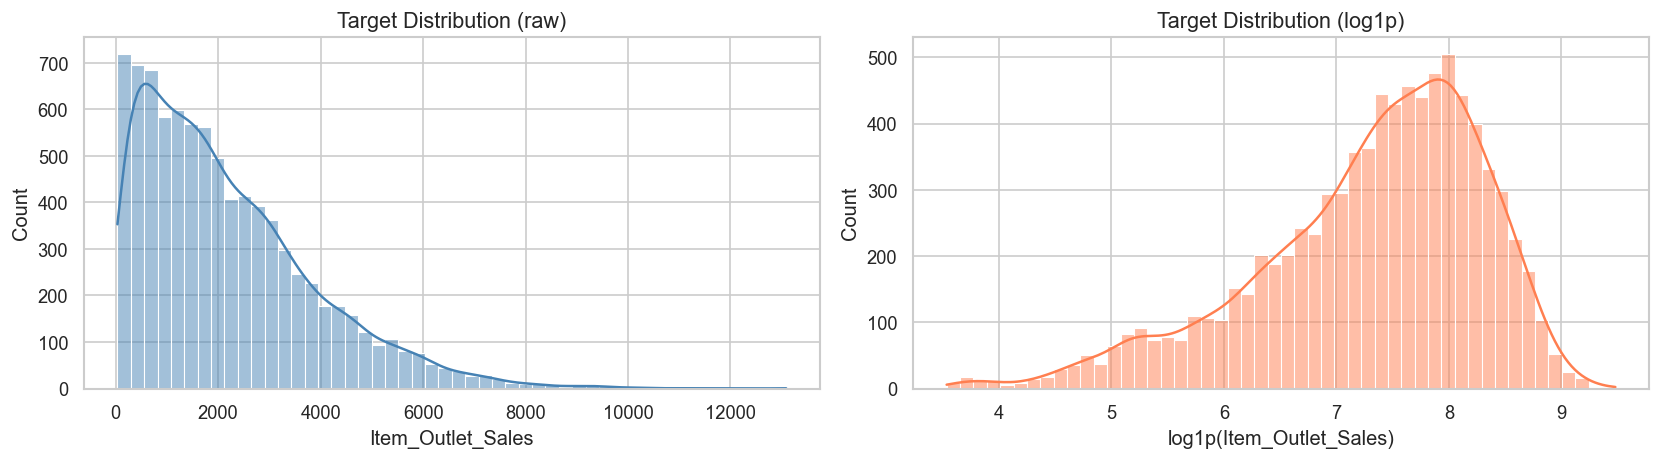

In [6]:
# ── Target distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train['Item_Outlet_Sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Target Distribution (raw)', fontsize=13)
axes[0].set_xlabel('Item_Outlet_Sales')

sns.histplot(np.log1p(train['Item_Outlet_Sales']), bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Target Distribution (log1p)', fontsize=13)
axes[1].set_xlabel('log1p(Item_Outlet_Sales)')

plt.tight_layout()
plt.savefig('plots/target_distribution.png', bbox_inches='tight')
plt.show()

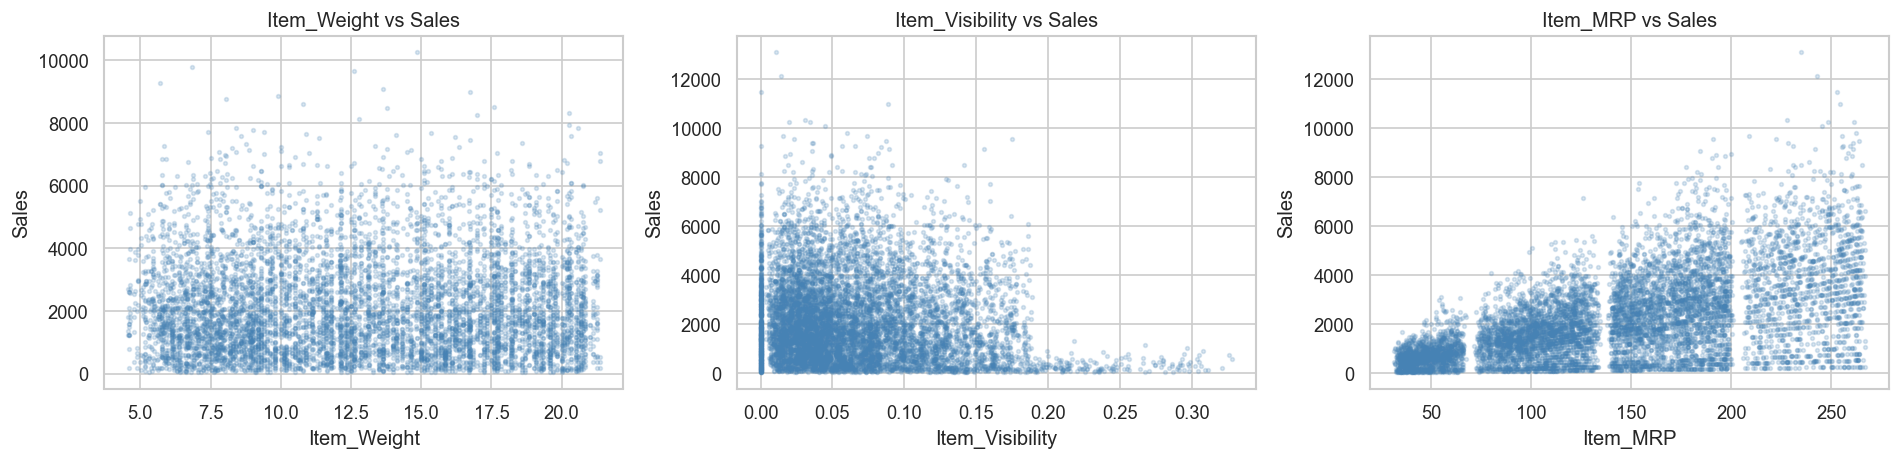

In [7]:
# ── Numerical features vs target ─────────────────────────────────────────────
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.scatter(train[col], train['Item_Outlet_Sales'], alpha=0.2, s=5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Sales')
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.savefig('plots/numerical_vs_target.png', bbox_inches='tight')
plt.show()

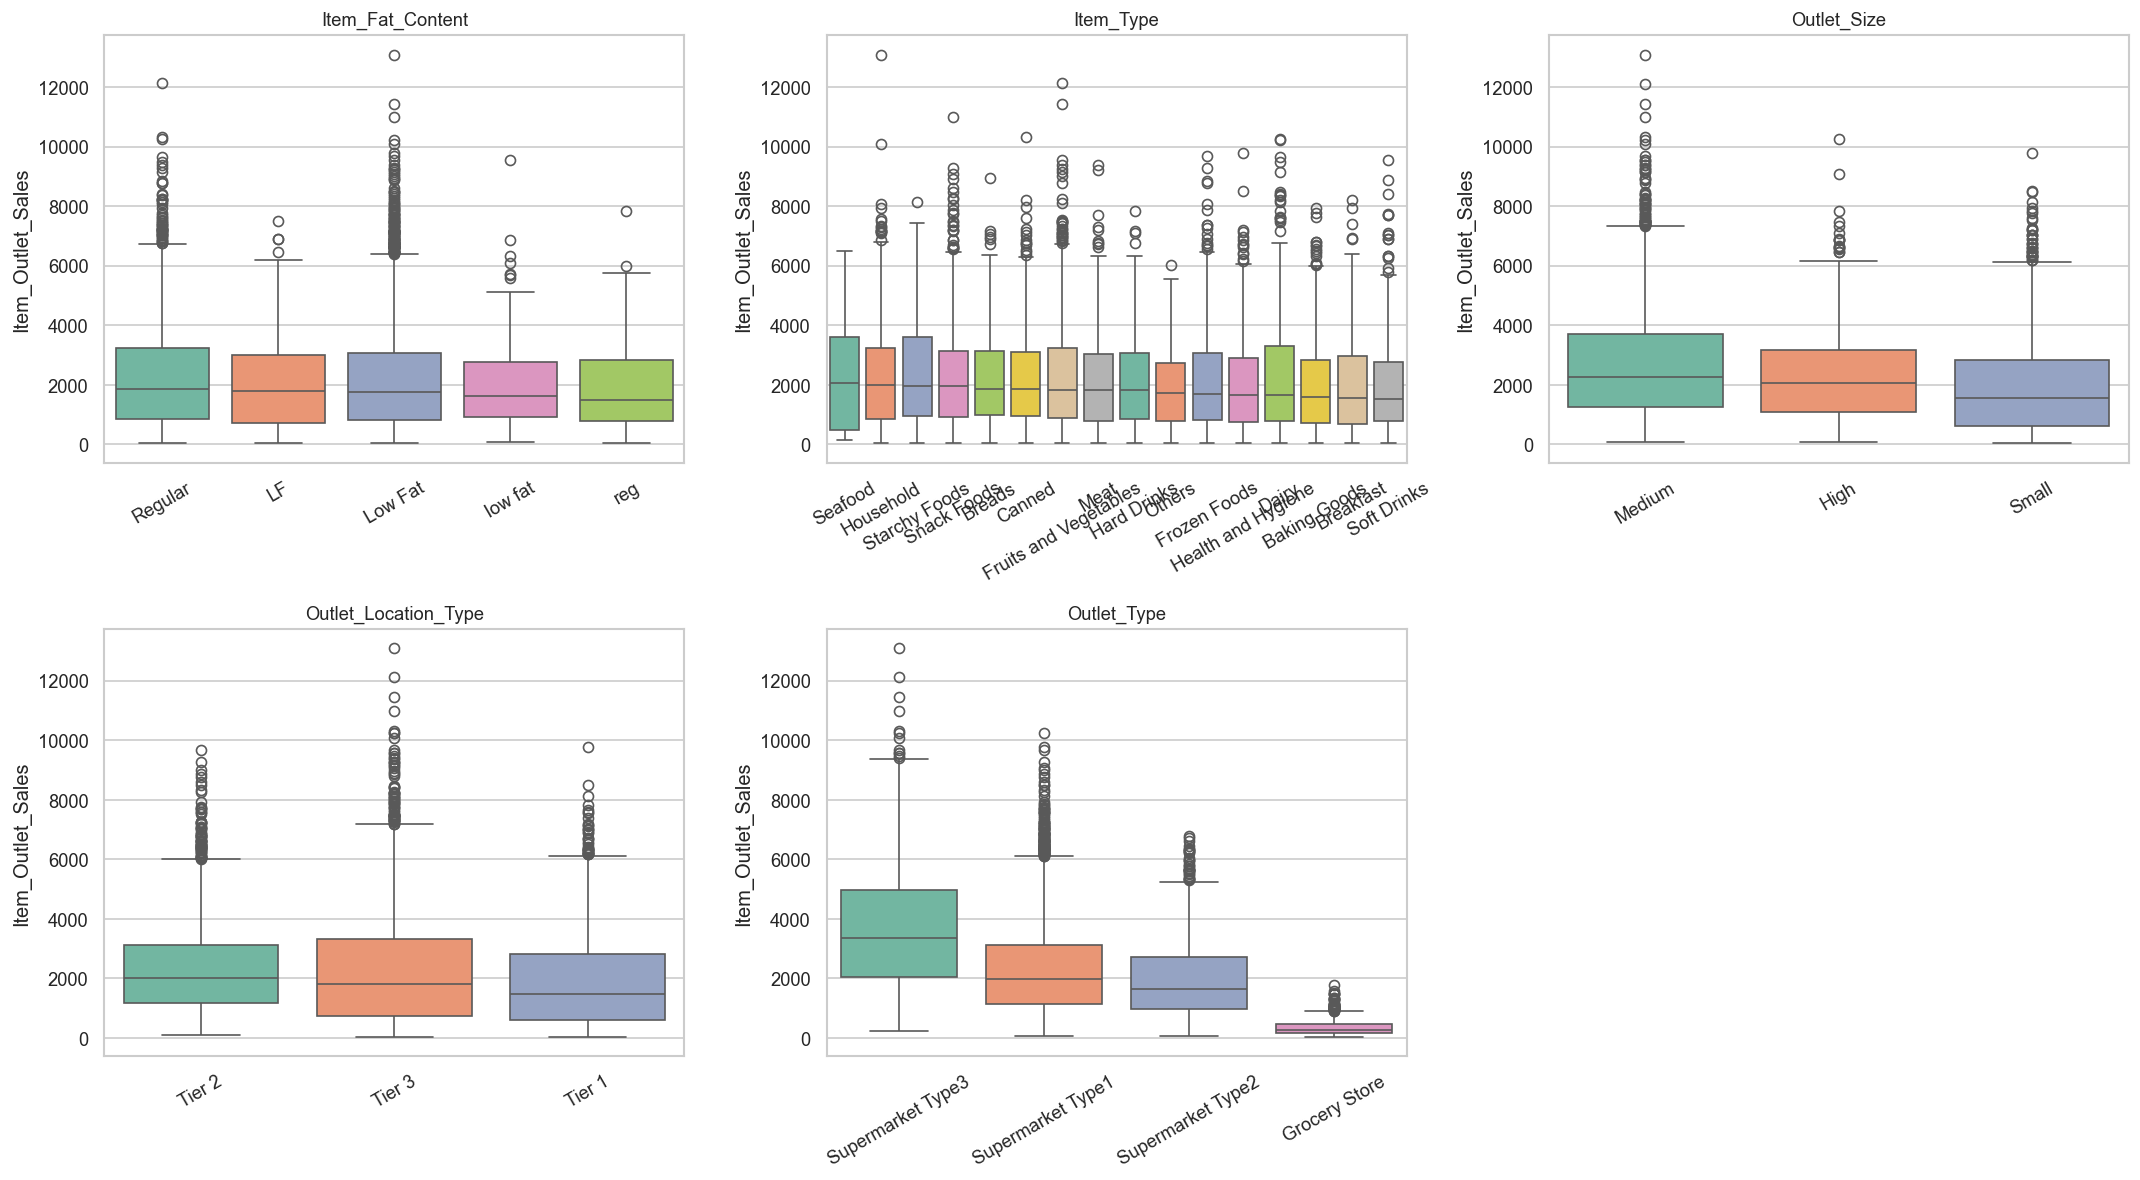

In [8]:
# ── Categorical features ──────────────────────────────────────────────────────
cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
            'Outlet_Location_Type', 'Outlet_Type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train.groupby(col)['Item_Outlet_Sales'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='Item_Outlet_Sales', order=order,
                ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('plots/categorical_vs_target.png', bbox_inches='tight')
plt.show()

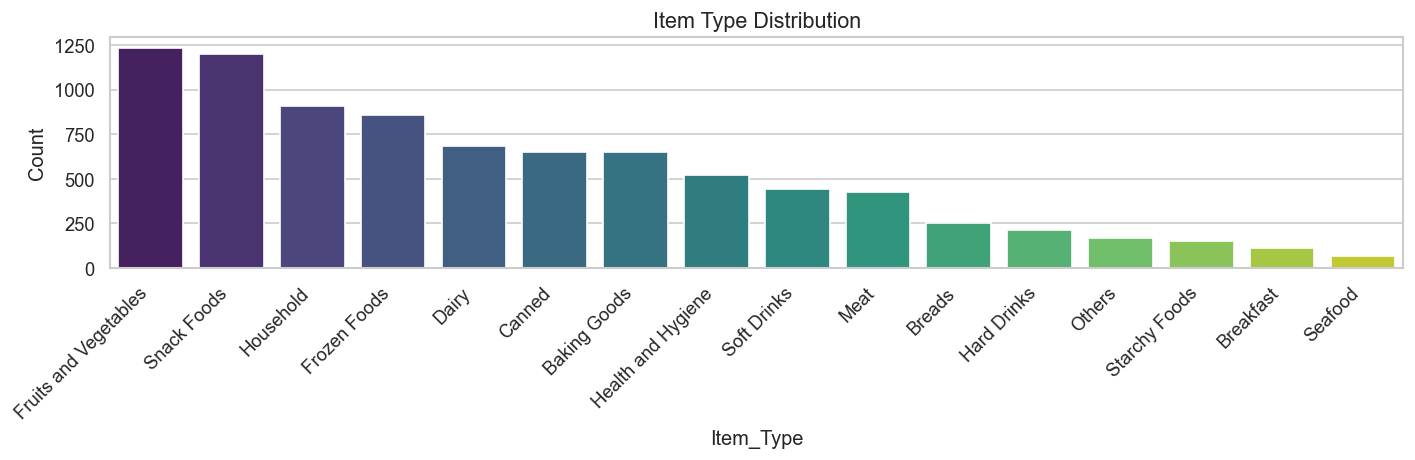

In [9]:
# ── Item_Type distribution ────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
counts = train['Item_Type'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Item Type Distribution', fontsize=13)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/item_type_distribution.png', bbox_inches='tight')
plt.show()

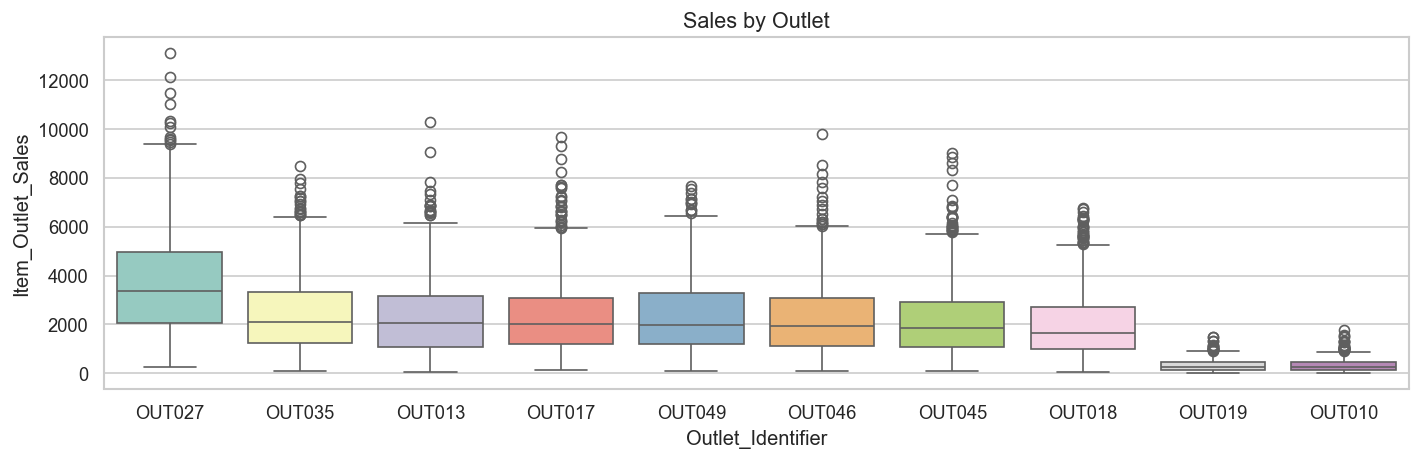

In [10]:
# ── Outlet-level sales ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
order = train.groupby('Outlet_Identifier')['Item_Outlet_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='Outlet_Identifier', y='Item_Outlet_Sales', order=order, palette='Set3')
plt.title('Sales by Outlet', fontsize=13)
plt.tight_layout()
plt.savefig('plots/outlet_sales.png', bbox_inches='tight')
plt.show()

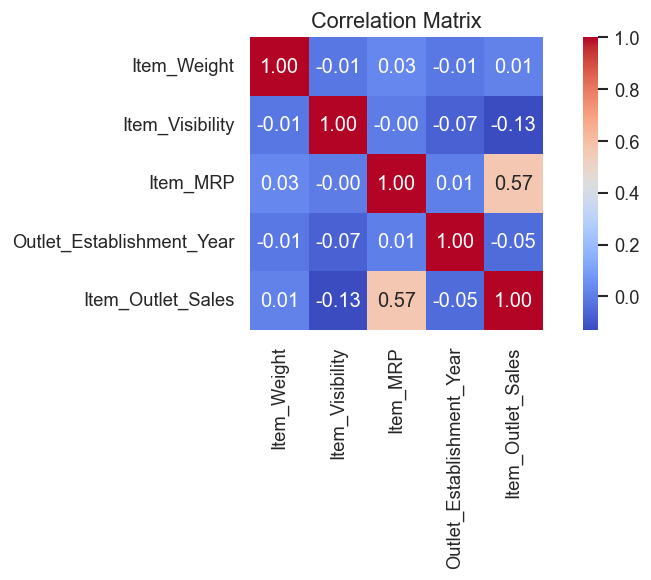

In [11]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
corr = train[['Item_Weight','Item_Visibility','Item_MRP','Outlet_Establishment_Year','Item_Outlet_Sales']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 3 · Feature Engineering

In [12]:
def engineer_features(df, is_train=True):
    df = df.copy()

    # ── 1. Standardise Item_Fat_Content ───────────────────────────────────────
    fat_map = {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}
    df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_map)

    # Non-consumables don't have fat content — mark separately
    non_consumable_types = ['Health and Hygiene', 'Household', 'Others']
    df.loc[df['Item_Type'].isin(non_consumable_types), 'Item_Fat_Content'] = 'Non-Consumable'

    # ── 2. Item category from identifier prefix ───────────────────────────────
    df['Item_Category'] = df['Item_Identifier'].str[:2]
    # FD = Food, DR = Drinks, NC = Non-Consumable
    cat_map = {'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'}
    df['Item_Category'] = df['Item_Category'].map(cat_map).fillna('Other')

    # ── 3. Outlet age ────────────────────────────────────────────────────────
    df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

    # ── 4. Impute Item_Weight with item-level mean ────────────────────────────
    if is_train:
        item_weight_mean = df.groupby('Item_Identifier')['Item_Weight'].mean()
        df['item_weight_mean_'] = item_weight_mean  # store for later
    else:
        # will be handled after combining with train stats
        pass

    df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(
        lambda x: x.fillna(x.mean())
    )
    # Fill remaining with overall mean
    df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

    # ── 5. Fix zero visibility (items not on display) ─────────────────────────
    zero_vis_mask = df['Item_Visibility'] == 0
    df.loc[zero_vis_mask, 'Item_Visibility'] = np.nan
    df['Item_Visibility'] = df.groupby('Item_Identifier')['Item_Visibility'].transform(
        lambda x: x.fillna(x.mean())
    )
    df['Item_Visibility'] = df['Item_Visibility'].fillna(df['Item_Visibility'].mean())

    # ── 6. Visibility ratio (item vs mean visibility in outlet) ───────────────
    outlet_vis_mean = df.groupby('Outlet_Identifier')['Item_Visibility'].transform('mean')
    df['Item_Visibility_Ratio'] = df['Item_Visibility'] / (outlet_vis_mean + 1e-9)

    # ── 7. Impute Outlet_Size ────────────────────────────────────────────────
    # Grocery Store → Small; Supermarket Type1 → Small; others filled by mode
    outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].apply(
        lambda x: x.mode()[0] if x.notna().any() else 'Small'
    )
    df['Outlet_Size'] = df.apply(
        lambda row: outlet_size_mode[row['Outlet_Type']]
        if pd.isna(row['Outlet_Size']) or row['Outlet_Size'] == ''
        else row['Outlet_Size'],
        axis=1
    )

    # ── 8. MRP price band ────────────────────────────────────────────────────
    df['MRP_Band'] = pd.cut(
        df['Item_MRP'],
        bins=[0, 70, 130, 200, 270],
        labels=['Budget', 'Mid', 'Premium', 'Luxury']
    ).astype(str)

    # ── 9. Log-transform Item_MRP ────────────────────────────────────────────
    df['Item_MRP_Log'] = np.log1p(df['Item_MRP'])

    # ── 10. Outlet × Category sales proxy ───────────────────────────────────
    df['Outlet_Type_Encoded'] = df['Outlet_Type'].map({
        'Grocery Store': 0,
        'Supermarket Type1': 1,
        'Supermarket Type2': 2,
        'Supermarket Type3': 3
    }).fillna(1).astype(int)

    return df


train_fe = engineer_features(train, is_train=True)
test_fe  = engineer_features(test,  is_train=False)

print('Feature engineering done.')
print('New columns:', [c for c in train_fe.columns if c not in train.columns])

Feature engineering done.
New columns: ['Item_Category', 'Outlet_Age', 'item_weight_mean_', 'Item_Visibility_Ratio', 'MRP_Band', 'Item_MRP_Log', 'Outlet_Type_Encoded']


In [13]:
# ── Encode categoricals ──────────────────────────────────────────────────────
cat_features = [
    'Item_Fat_Content', 'Item_Type', 'Item_Category', 'MRP_Band',
    'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'
]

encoders = {}
for col in cat_features:
    le = LabelEncoder()
    # fit on combined to handle unseen categories
    combined = pd.concat([train_fe[col], test_fe[col]], axis=0).astype(str)
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col]  = le.transform(test_fe[col].astype(str))
    encoders[col] = le

print('Encoding done.')

Encoding done.


In [14]:
# ── Define feature set ───────────────────────────────────────────────────────
DROP_COLS = ['Item_Identifier', 'Outlet_Identifier', 'Item_Outlet_Sales',
             'Outlet_Establishment_Year', 'item_weight_mean_']

FEATURES = [c for c in train_fe.columns
            if c not in DROP_COLS and c in test_fe.columns]

X     = train_fe[FEATURES].values
y     = train_fe['Item_Outlet_Sales'].values
X_sub = test_fe[FEATURES].values

print(f'Features ({len(FEATURES)}):', FEATURES)

Features (14): ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category', 'Outlet_Age', 'Item_Visibility_Ratio', 'MRP_Band', 'Item_MRP_Log', 'Outlet_Type_Encoded']


## 4 · Model Benchmarking

In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_evaluate(model, X, y, name):
    rmse_scores = []
    r2_scores   = []
    for fold, (tr, val) in enumerate(kf.split(X), 1):
        model.fit(X[tr], y[tr])
        preds = model.predict(X[val])
        rmse  = np.sqrt(mean_squared_error(y[val], preds))
        r2    = r2_score(y[val], preds)
        rmse_scores.append(rmse)
        r2_scores.append(r2)
    print(f'{name:30s}  RMSE: {np.mean(rmse_scores):,.0f} ± {np.std(rmse_scores):,.0f}  |  R²: {np.mean(r2_scores):.4f}')
    return np.mean(rmse_scores), np.mean(r2_scores)


print(f'{"Model":30s}  RMSE             |  R²')
print('-' * 65)

results = {}

# Ridge
ridge = Ridge(alpha=10)
rmse, r2 = cv_evaluate(ridge, X, y, 'Ridge')
results['Ridge'] = {'RMSE': rmse, 'R2': r2}

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=SEED, n_jobs=-1)
rmse, r2 = cv_evaluate(rf, X, y, 'Random Forest')
results['Random Forest'] = {'RMSE': rmse, 'R2': r2}

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0
)
rmse, r2 = cv_evaluate(xgb_model, X, y, 'XGBoost')
results['XGBoost'] = {'RMSE': rmse, 'R2': r2}

# LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
rmse, r2 = cv_evaluate(lgb_model, X, y, 'LightGBM')
results['LightGBM'] = {'RMSE': rmse, 'R2': r2}

Model                           RMSE             |  R²
-----------------------------------------------------------------
Ridge                           RMSE: 1,203 ± 35  |  R²: 0.5020


Random Forest                   RMSE: 1,090 ± 35  |  R²: 0.5916


XGBoost                         RMSE: 1,145 ± 34  |  R²: 0.5492


LightGBM                        RMSE: 1,121 ± 36  |  R²: 0.5680


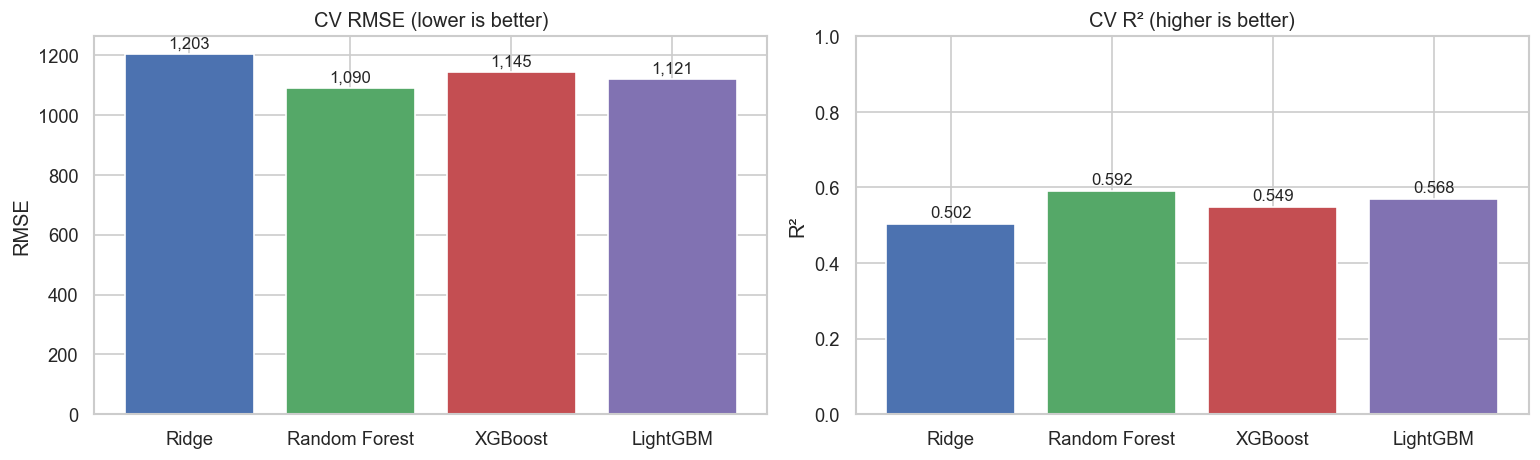


Best model: Random Forest


In [16]:
# ── Comparison chart ──────────────────────────────────────────────────────────
names = list(results.keys())
rmses = [results[m]['RMSE'] for m in names]
r2s   = [results[m]['R2']   for m in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars1 = axes[0].bar(names, rmses, color=colors)
axes[0].set_title('CV RMSE (lower is better)', fontsize=12)
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars1, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(names, r2s, color=colors)
axes[1].set_title('CV R² (higher is better)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('plots/model_comparison.png', bbox_inches='tight')
plt.show()
print('\nBest model:', min(results, key=lambda k: results[k]['RMSE']))

## 5 · Hyperparameter Tuning (XGBoost)

In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [400, 500, 600, 800],
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.03, 0.05, 0.08, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha':        [0.0, 0.1, 0.5, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0]
}

xgb_base = xgb.XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0)

search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5, refit=True,
    random_state=SEED, n_jobs=-1, verbose=1
)
search.fit(X, y)

print('\nBest RMSE:', -search.best_score_)
print('Best params:', search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits



Best RMSE: 1102.3166856959201
Best params: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [18]:
best_model = search.best_estimator_

# Final cross-val check on tuned model
cv_rmse, cv_r2 = cv_evaluate(best_model, X, y, 'Tuned XGBoost')

Tuned XGBoost                   RMSE: 1,098 ± 34  |  R²: 0.5857


## 6 · Feature Importance

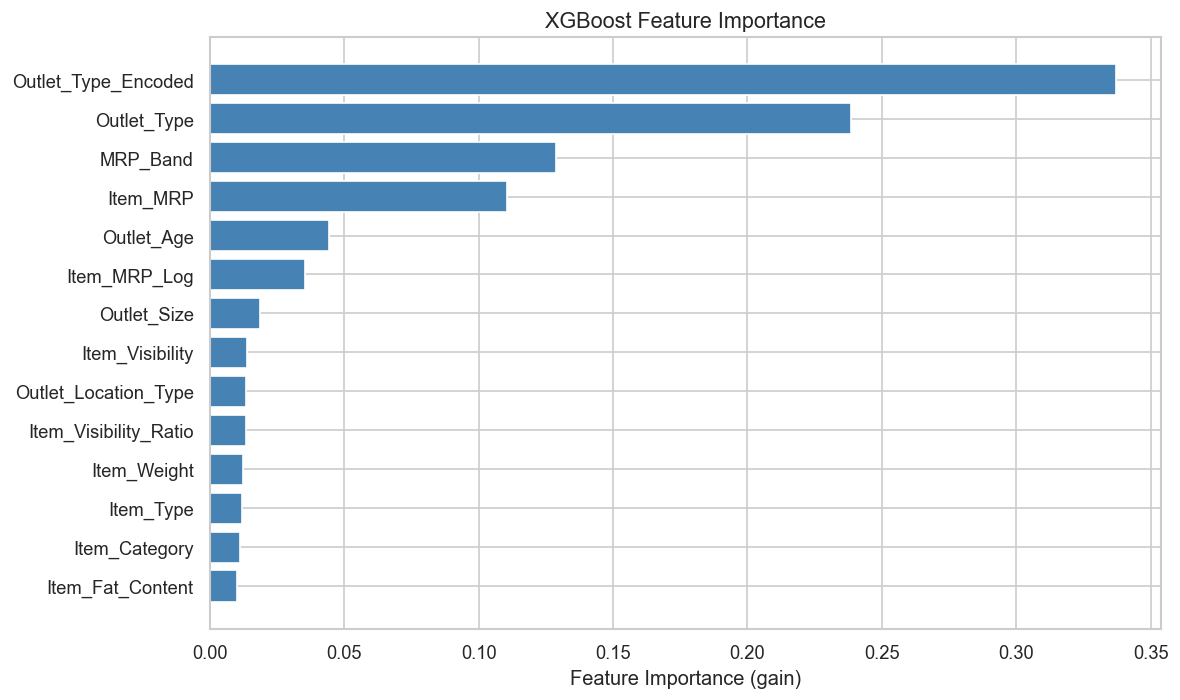

In [19]:
best_model.fit(X, y)
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})\
            .sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance (gain)')
plt.title('XGBoost Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('plots/feature_importance.png', bbox_inches='tight')
plt.show()

## 7 · Predictions & Submission

In [20]:
y_pred_sub = best_model.predict(X_sub)
y_pred_sub = np.maximum(y_pred_sub, 0)  # sales can't be negative

submission = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'],
    'Item_Outlet_Sales': y_pred_sub
})
submission.to_csv('submission.csv', index=False)
print('Submission saved.')
submission.head(10)

Submission saved.


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1651.363892
1,FDW14,OUT017,1404.883301
2,NCN55,OUT010,552.298889
3,FDQ58,OUT017,2575.477783
4,FDY38,OUT027,6254.310547
5,FDH56,OUT046,1790.209106
6,FDL48,OUT018,565.160522
7,FDC48,OUT027,2071.069336
8,FDN33,OUT045,1513.665894
9,FDA36,OUT017,2925.055420


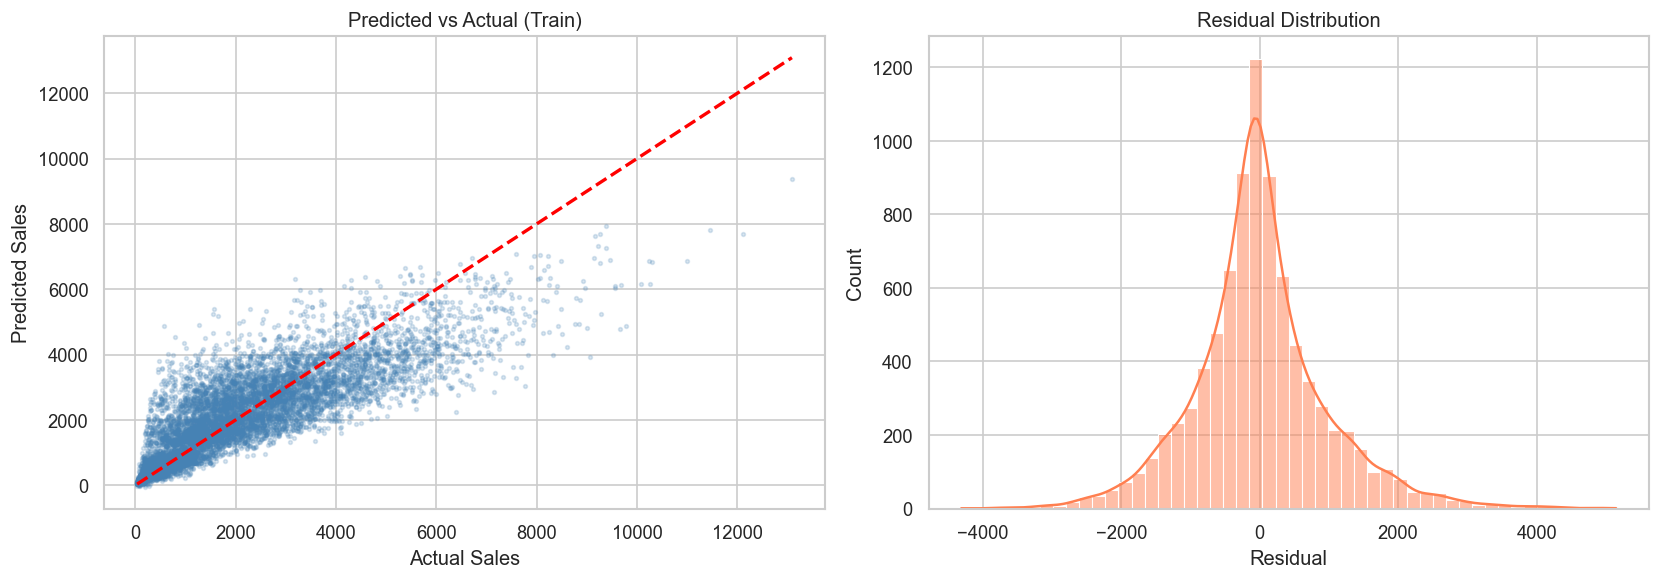

Train  RMSE: 964  |  R²: 0.6810
CV     RMSE: 1,098  |  R²: 0.5857


In [21]:
# Predicted vs actual on train
best_model.fit(X, y)
y_train_pred = best_model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y, y_train_pred, alpha=0.2, s=5, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Predicted vs Actual (Train)', fontsize=12)

residuals = y - y_train_pred
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution', fontsize=12)

plt.tight_layout()
plt.savefig('plots/prediction_analysis.png', bbox_inches='tight')
plt.show()

train_rmse = np.sqrt(mean_squared_error(y, y_train_pred))
train_r2   = r2_score(y, y_train_pred)
print(f'Train  RMSE: {train_rmse:,.0f}  |  R²: {train_r2:.4f}')
print(f'CV     RMSE: {cv_rmse:,.0f}  |  R²: {cv_r2:.4f}')

## 8 · Save Model & Metadata

In [22]:
# Save model
with open('models/xgb_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save encoders
with open('models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# Save feature list and metadata
meta = {
    'features': FEATURES,
    'cat_features': cat_features,
    'cv_rmse': round(cv_rmse, 2),
    'cv_r2': round(cv_r2, 4),
    'best_params': search.best_params_,
    'model_comparison': {
        k: {'rmse': round(v['RMSE'], 2), 'r2': round(v['R2'], 4)}
        for k, v in results.items()
    }
}

with open('models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Model, encoders, and metadata saved.')
print(json.dumps(meta, indent=2))

Model, encoders, and metadata saved.
{
  "features": [
    "Item_Weight",
    "Item_Fat_Content",
    "Item_Visibility",
    "Item_Type",
    "Item_MRP",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type",
    "Item_Category",
    "Outlet_Age",
    "Item_Visibility_Ratio",
    "MRP_Band",
    "Item_MRP_Log",
    "Outlet_Type_Encoded"
  ],
  "cat_features": [
    "Item_Fat_Content",
    "Item_Type",
    "Item_Category",
    "MRP_Band",
    "Outlet_Identifier",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
  ],
  "cv_rmse": 1097.55,
  "cv_r2": 0.5857,
  "best_params": {
    "subsample": 0.7,
    "reg_lambda": 2.0,
    "reg_alpha": 0.1,
    "n_estimators": 600,
    "max_depth": 4,
    "learning_rate": 0.03,
    "colsample_bytree": 0.7
  },
  "model_comparison": {
    "Ridge": {
      "rmse": 1203.42,
      "r2": 0.502
    },
    "Random Forest": {
      "rmse": 1089.81,
      "r2": 0.5916
    },
    "XGBoost": {
      "rmse": 1144.93,
      "r2": 0.5492
  

In [23]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 55)
print('         BIGMART SALES PREDICTION — SUMMARY')
print('=' * 55)
print(f'  Training samples  : {len(train):,}')
print(f'  Test samples      : {len(test):,}')
print(f'  Features used     : {len(FEATURES)}')
print(f'  Best model        : Tuned XGBoost')
print(f'  CV RMSE           : {cv_rmse:,.2f}')
print(f'  CV R²             : {cv_r2:.4f}')
print('=' * 55)

         BIGMART SALES PREDICTION — SUMMARY
  Training samples  : 8,523
  Test samples      : 5,681
  Features used     : 14
  Best model        : Tuned XGBoost
  CV RMSE           : 1,097.55
  CV R²             : 0.5857
